## Multi-core gather kernel

Run `make profile_mcgather` to collect the data.

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

_LEGEND_MARKER_SCALE = 1.75
_MARKERS = ["o", "^", "s", "X"]

_SNS_PARAMS = {"hue":'S', "style":'S', "markers":_MARKERS, "dashes":True}

In [15]:
PREFIX_PATH = "../../"
dtype="fp16"

gather_df = pd.concat(map(pd.read_csv, glob(join(PREFIX_PATH,  f"*mcgather*.csv"))))
gather_df["S"] = "MCGather"
gather_df["in_bytes_per_elem"] = gather_df["dtype"].map({"fp16": 2, "fp32": 4})

gather_df['mem_bytes'] = (gather_df['size'] * gather_df["in_bytes_per_elem"])  + gather_df['outputsize'] * gather_df["in_bytes_per_elem"] + gather_df['outputsize'] * 4
gather_df['bw_gbps'] = (gather_df['mem_bytes']) / (gather_df['time_us']*1000) #GB/s


In [16]:
gather_df.head()

,operator,dtype,size,density,outputsize,time_us,S,in_bytes_per_elem,mem_bytes,bw_gbps
0,mcgather_64_fp16,fp16,81920,None,1280.0,107.19,MCGather,2,171520.0,1.600149
1,mcgather_64_fp16,fp16,2703360,None,42240.0,135.55,MCGather,2,5660160.0,41.756990
2,mcgather_64_fp16,fp16,5324800,None,83200.0,169.04,MCGather,2,11148800.0,65.953620
3,mcgather_64_fp16,fp16,7946240,None,124160.0,205.72,MCGather,2,16637440.0,80.874198
4,mcgather_64_fp16,fp16,10567680,None,165120.0,243.31,MCGather,2,22126080.0,90.937816


/tmp/ipykernel_569093/2370206161.py:1: UserWarning: The markers list has more values (4) than needed (1), which may not be intended.
  ax = sns.lineplot(data=gather_df, x='size', y='bw_gbps', **_SNS_PARAMS)


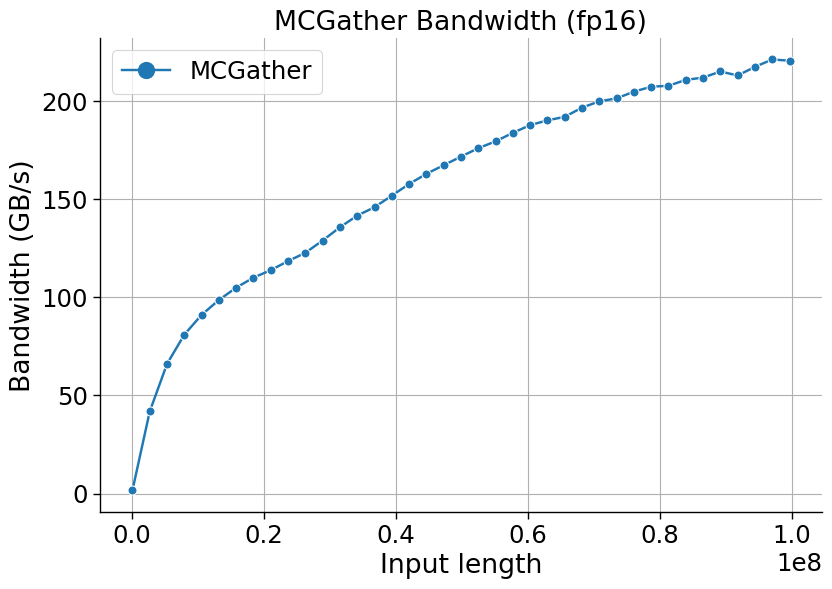

<Figure size 870x627 with 0 Axes>

In [17]:
ax = sns.lineplot(data=gather_df, x='size', y='bw_gbps', **_SNS_PARAMS)

ax.set_title(f"MCGather Bandwidth ({dtype})")
ax.set_xlabel("Input length")
ax.set_ylabel("Bandwidth (GB/s)")
sns.despine(right = True)
plt.legend(markerscale=_LEGEND_MARKER_SCALE)
plt.grid()

plt.tight_layout()

fig = ax.get_figure()
fig.savefig(f"mc_gather_bw_{dtype}.png")
plt.show()
plt.clf()